In [1]:
import os

import duckdb
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from pathlib import Path
import numpy as np
import pandas as pd

In [ ]:
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]
DATABASE_PATH = "../../database/eBuS.duckdb"
OUTPUT_PATH = Path(r"C:\Users\ralop\Nextcloud\Masterarbeit\Grafiken\NewPlots")
VEHICLE_DICT = {"Ebusco2.2electric12m": "Ebusco 2.2", "SolarisUrbino12electric": "Urbino 12", "SolarisUrbino18electric": "Urbino 18"}

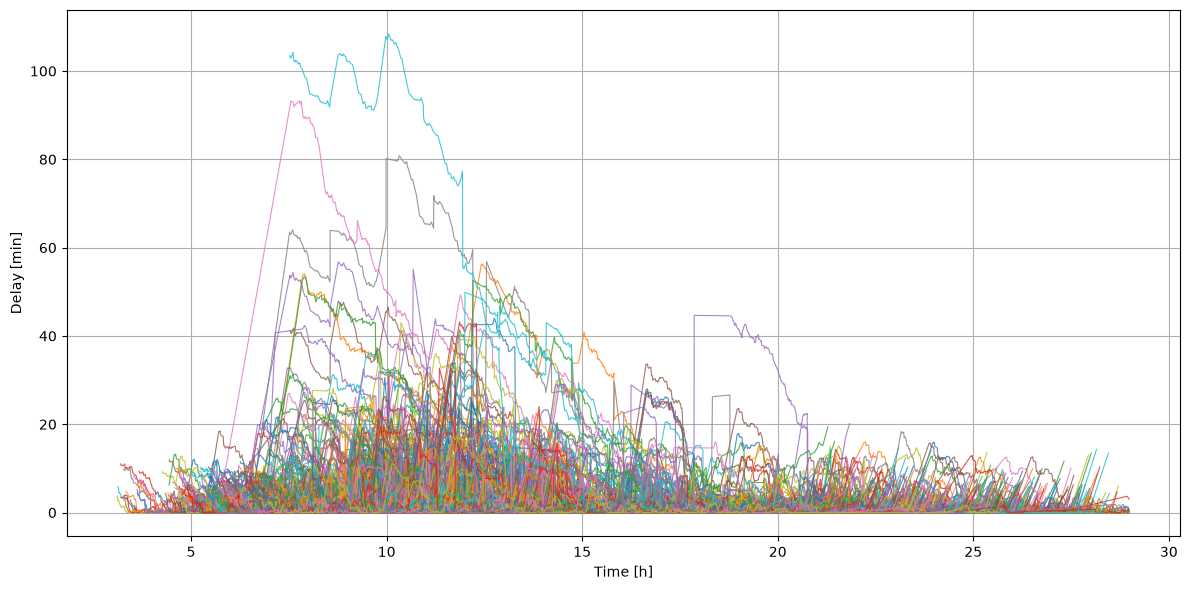

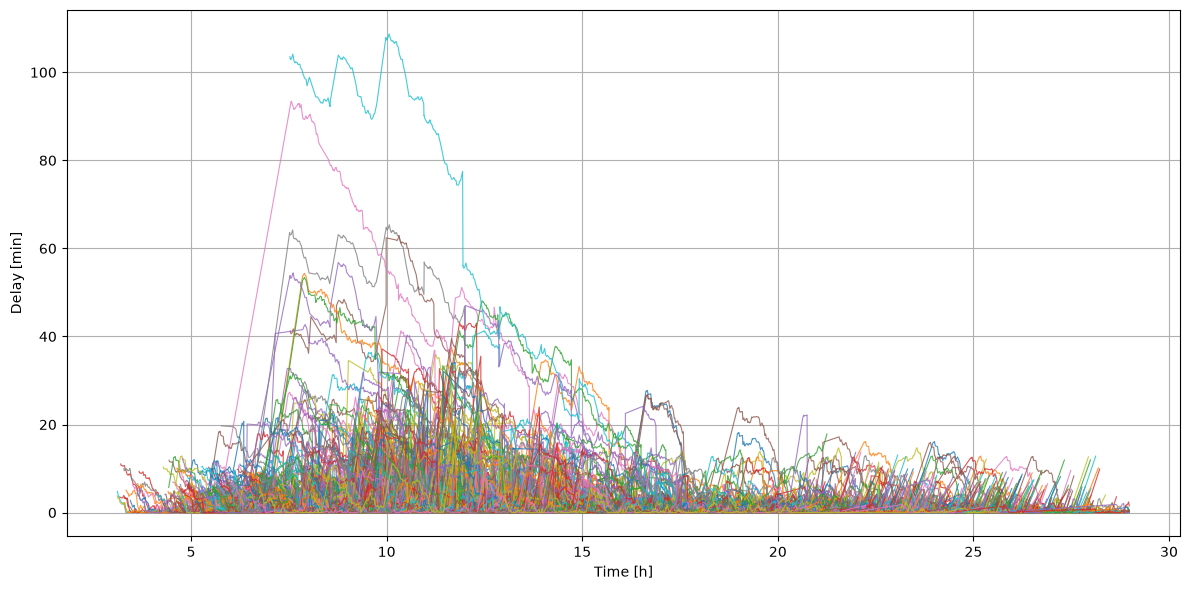

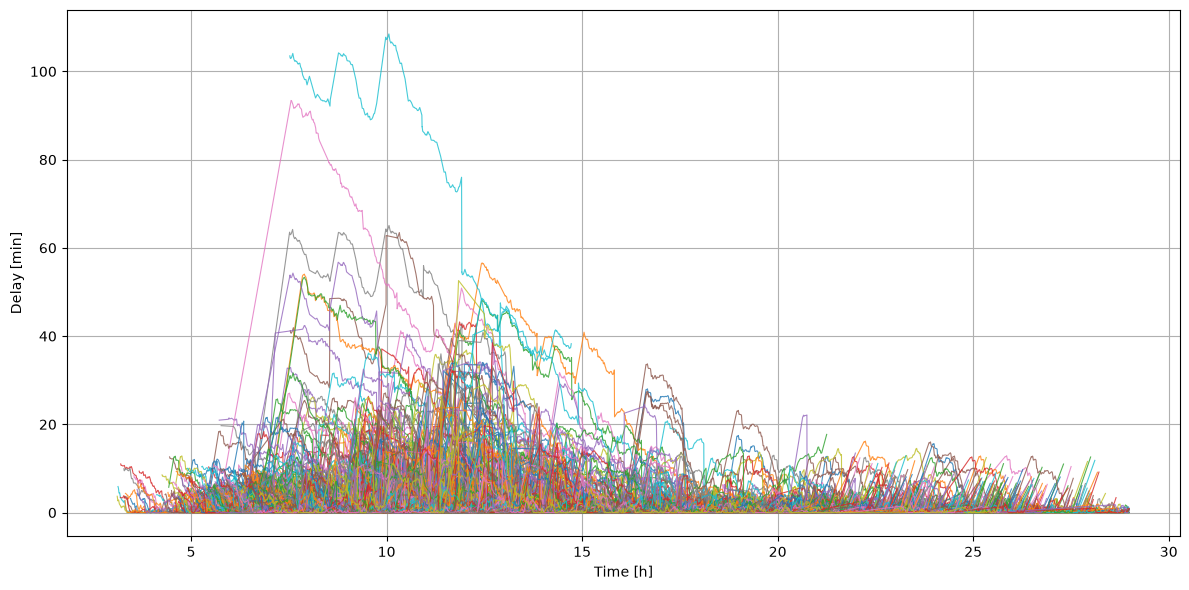

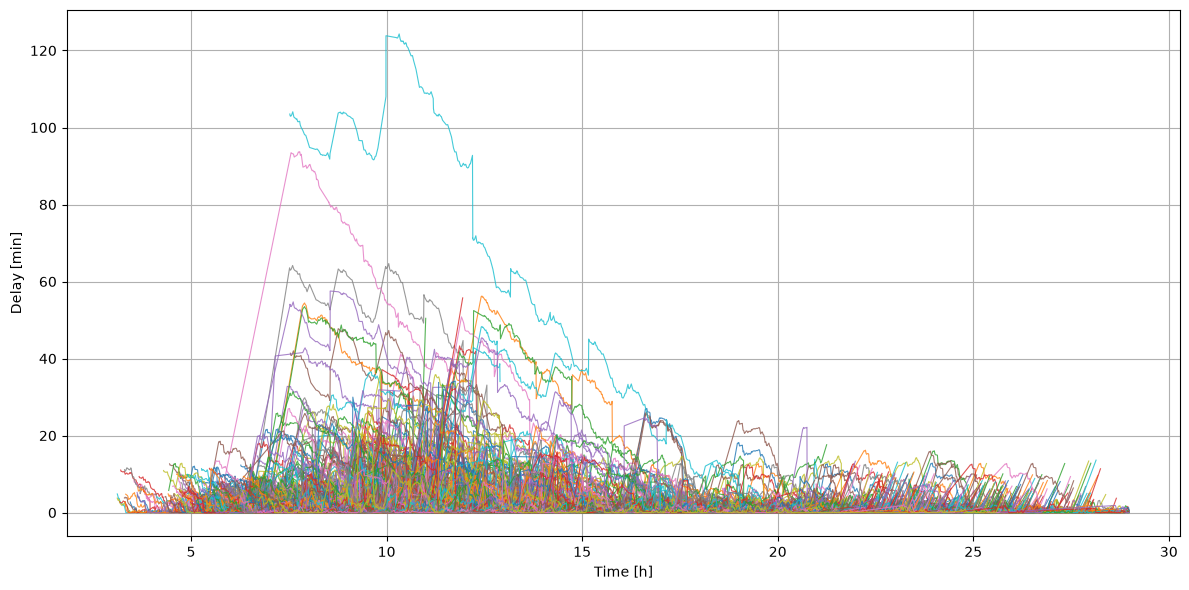

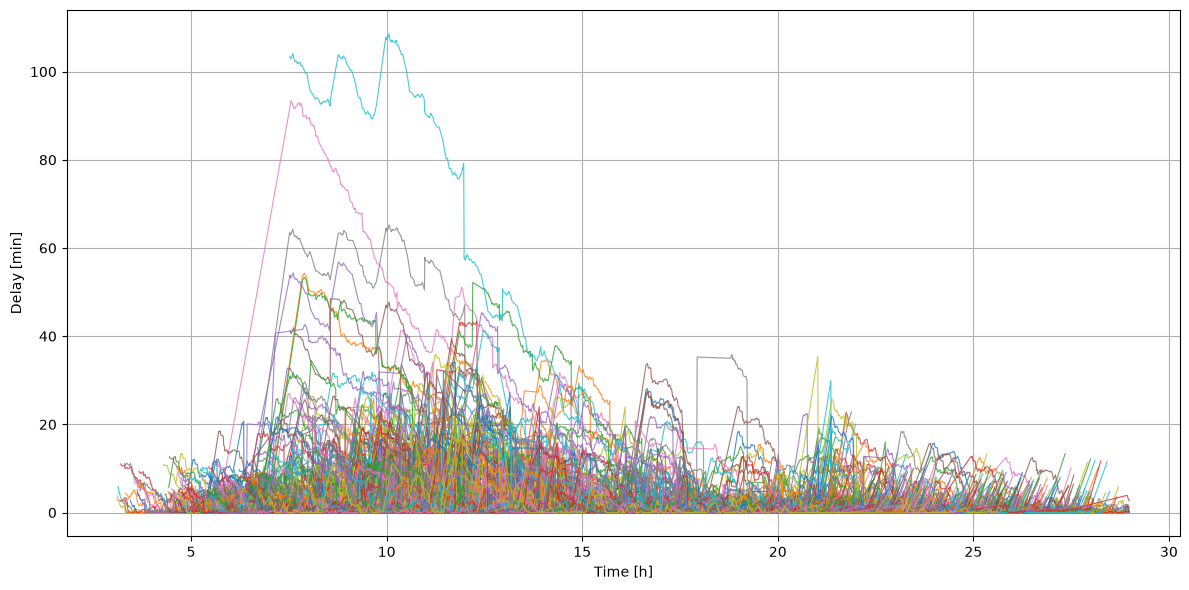

Saved all summer delay plots.


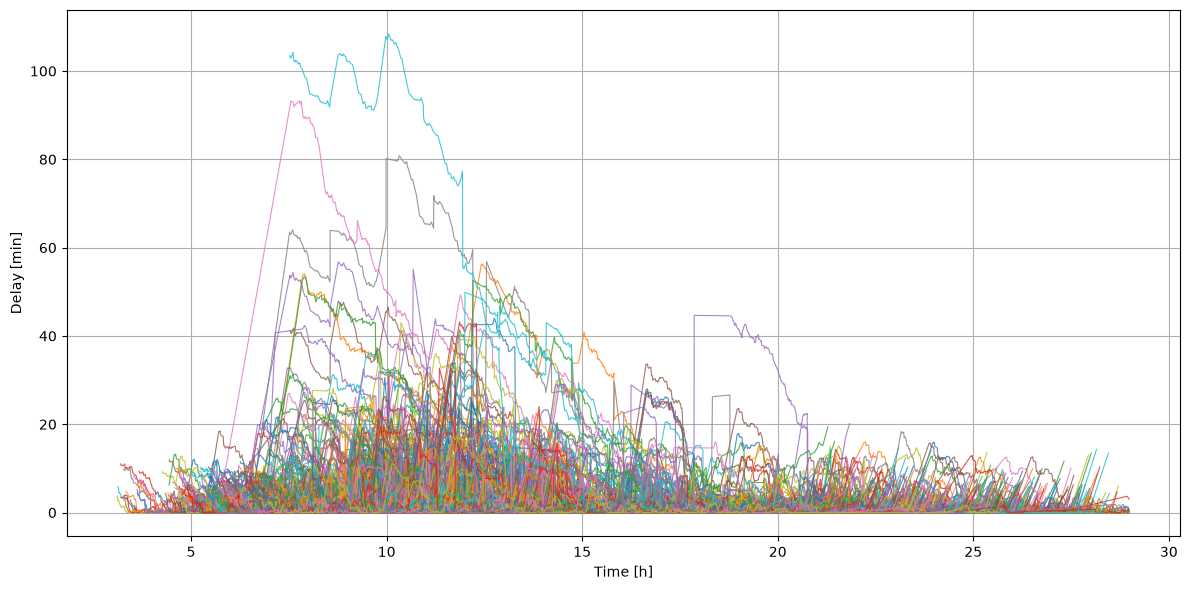

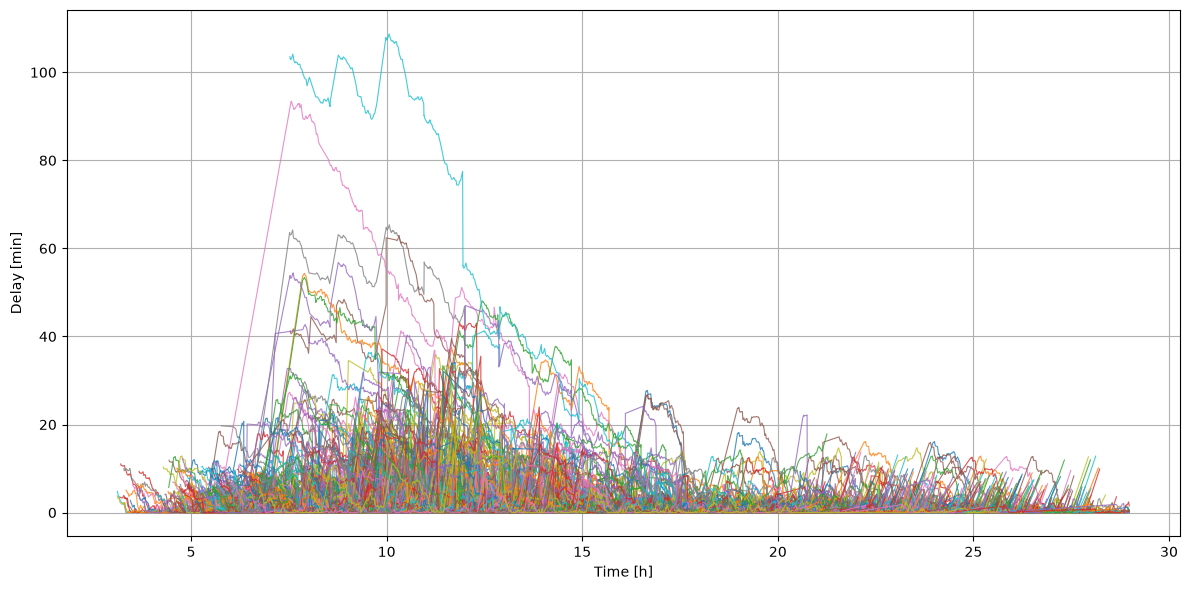

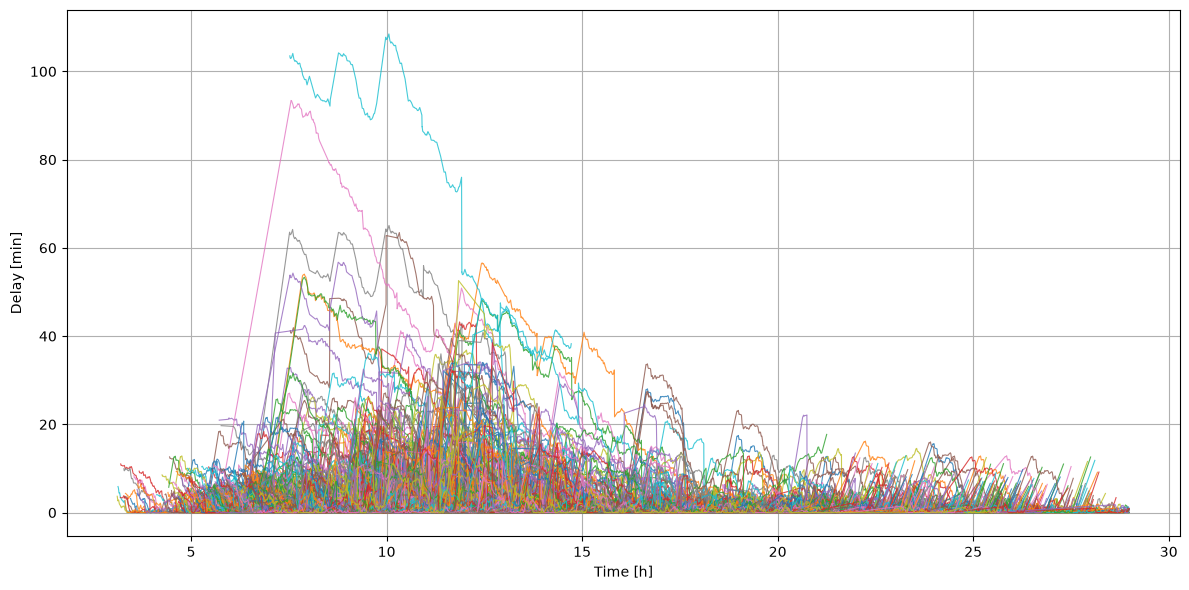

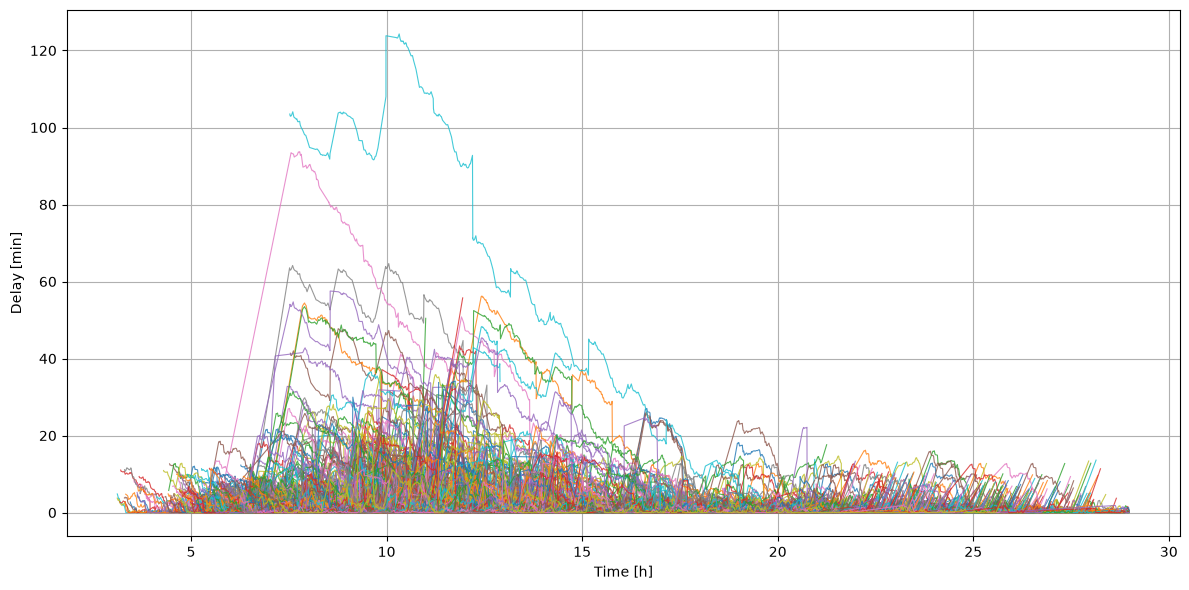

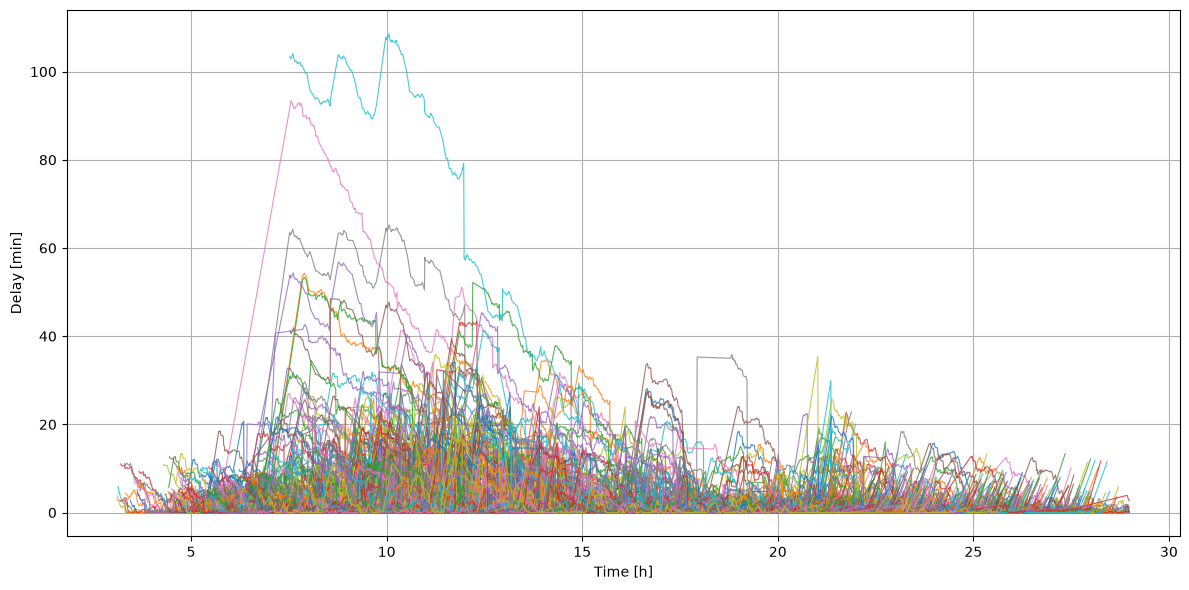

Saved all summer delay plots.


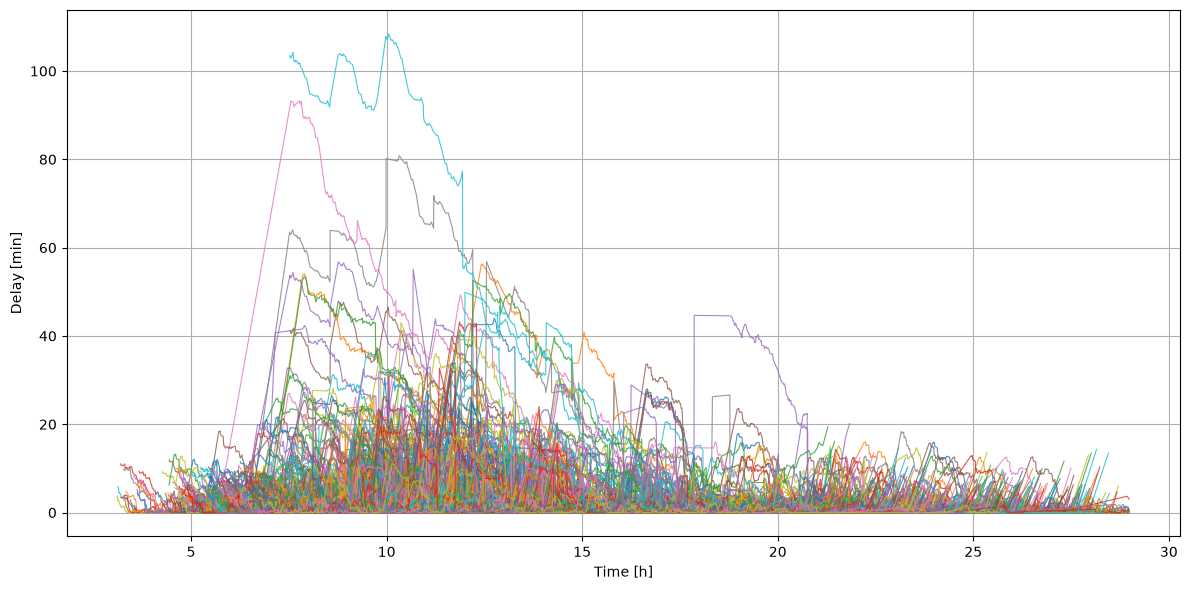

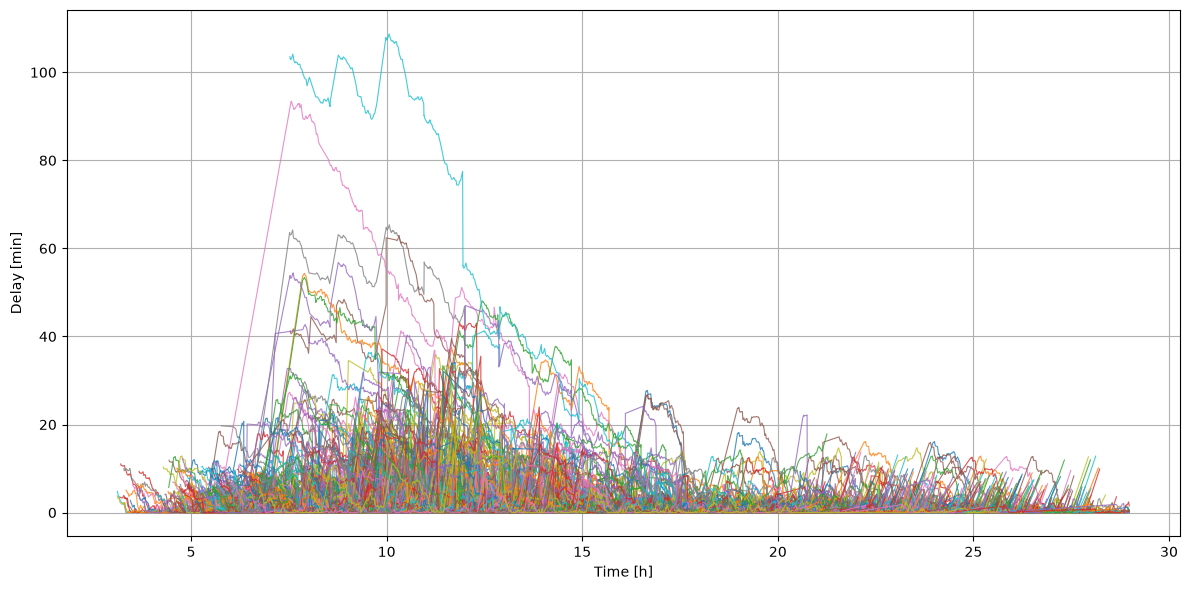

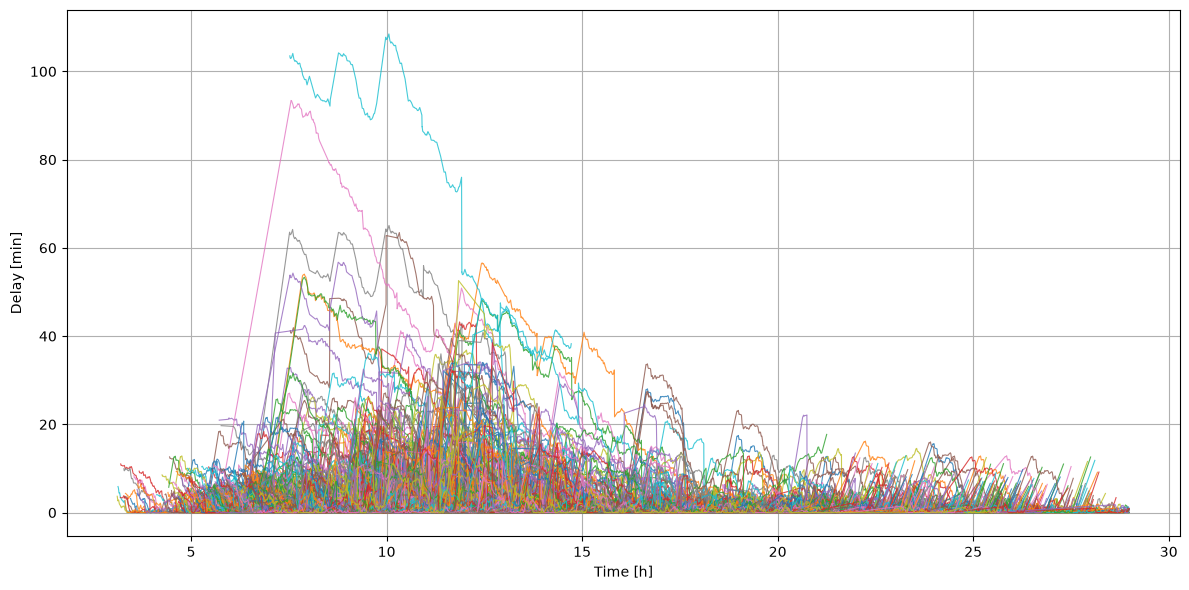

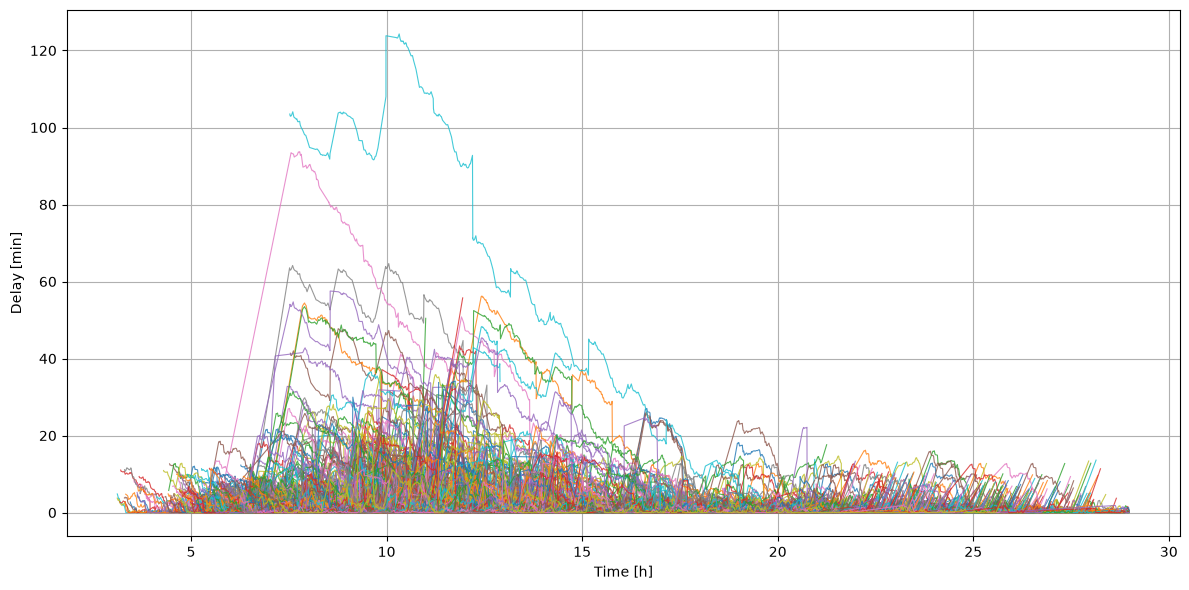

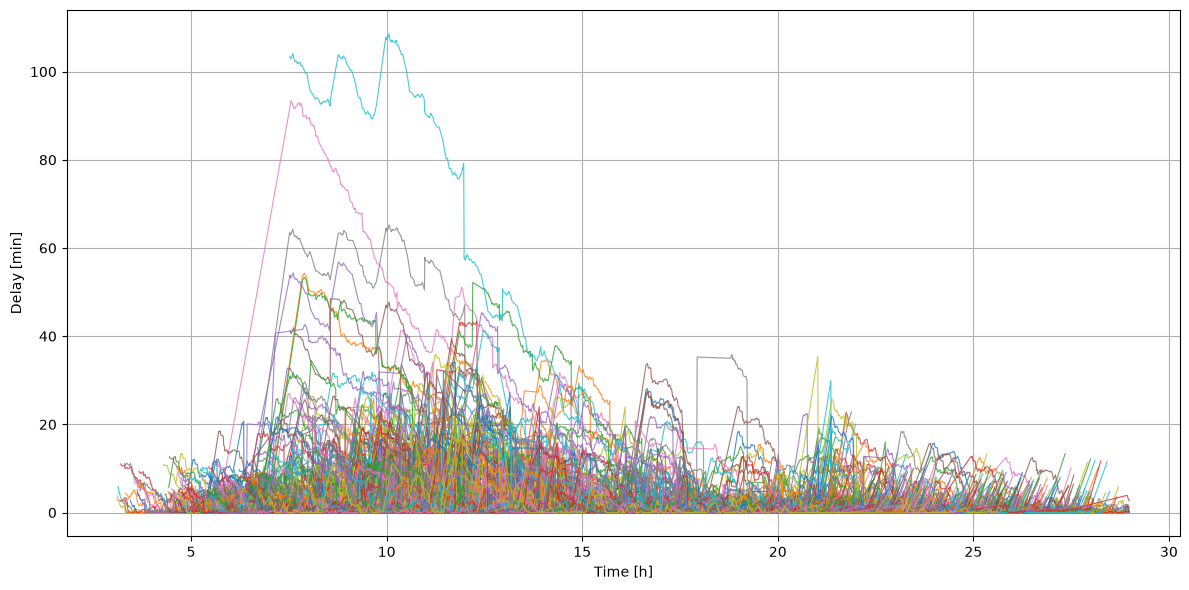

Saved all summer delay plots.


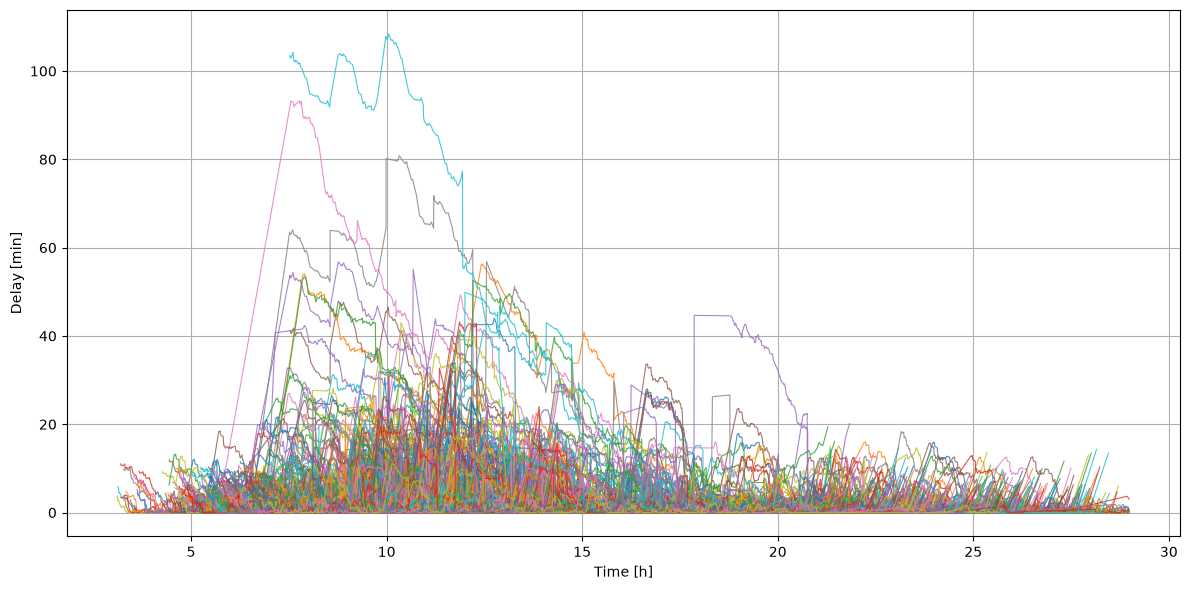

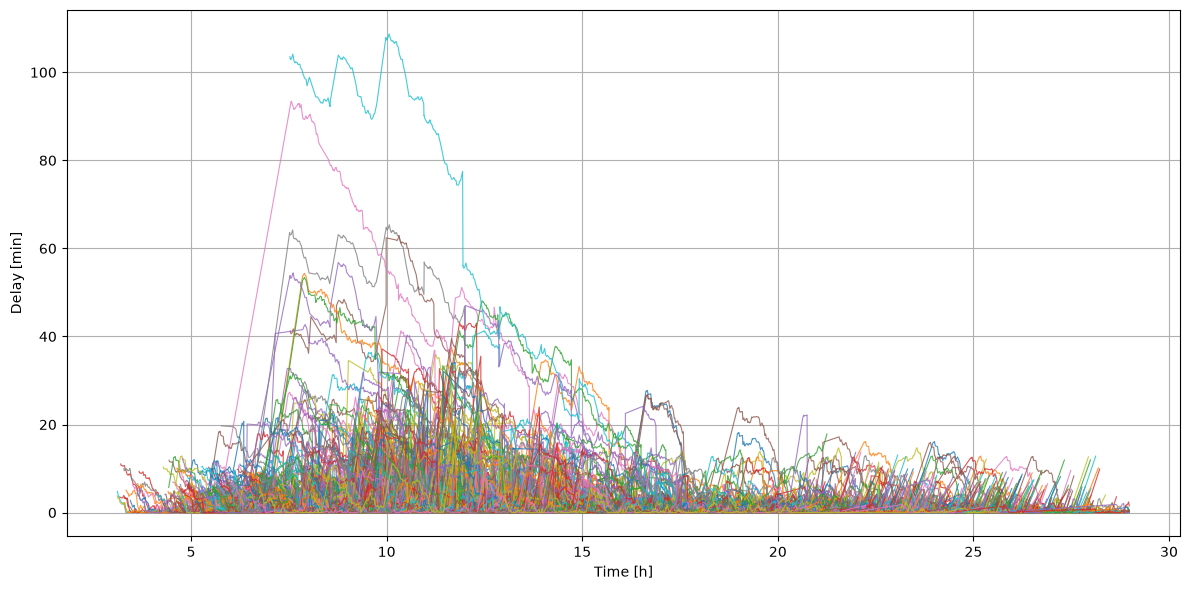

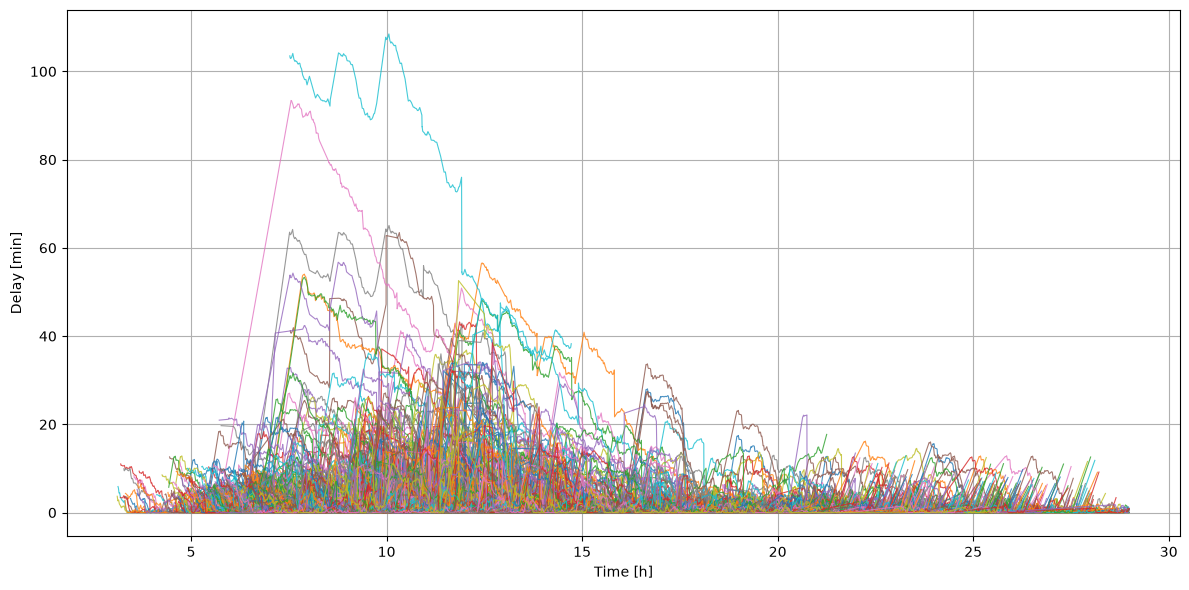

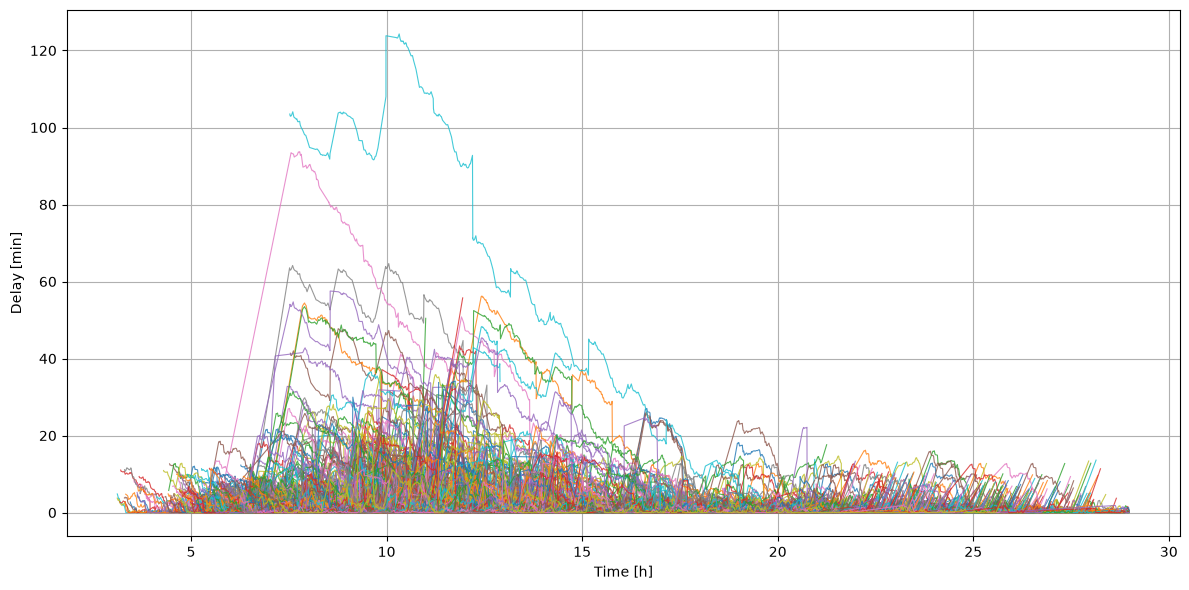

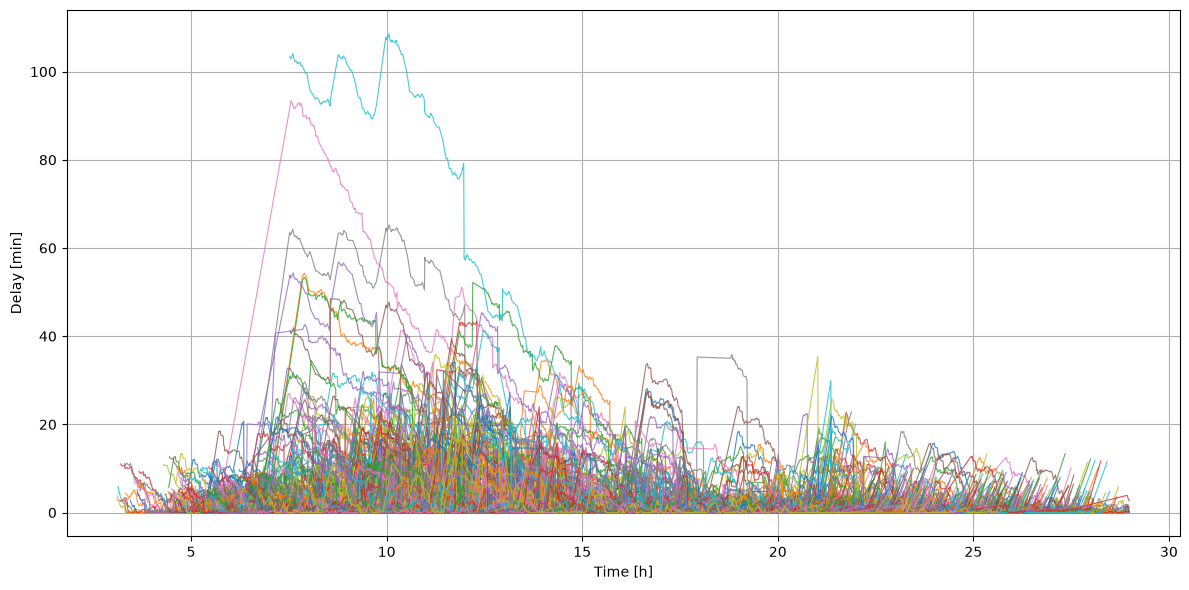

Saved all summer delay plots.


In [5]:
# AI-generated on 2026-09-14

con = duckdb.connect(DATABASE_PATH)

df = con.execute("""
    SELECT 
        stopinfo_delay,
        stopinfo_started, 
        stopinfo_id, 
        scenario, 
        seed
    FROM multirun_stopinfo
""").fetchdf()

con.close()

# Convert delay from seconds to minutes
df["stopinfo_delay"] = df["stopinfo_delay"] / 60

for scenario in ["summer", "winter", "reduced", "increased"]:

    subset = df[df["scenario"] == scenario]

    for seed in [65, 67, 68, 70, 75]:

        # Select only the current seed
        seed_df = subset[subset["seed"] == seed]

        fig, ax = plt.subplots(figsize=(12, 6))

        # Plot one line per vehicle
        for vehicle_id, vehicle_df in seed_df.groupby("stopinfo_id"):

            # Remove leading zero-delay values for this vehicle
            nonzero_idx = vehicle_df.index[
                vehicle_df["stopinfo_delay"] != 0
            ]

            if len(nonzero_idx) == 0:
                continue

            # Start at the first non-zero delay
            vehicle_df = vehicle_df.loc[nonzero_idx[0]:]

            ax.plot(
                vehicle_df["stopinfo_started"] / 3600,
                vehicle_df["stopinfo_delay"],
                label=str(vehicle_id),
                linewidth=0.8,
                alpha=0.8,
            )

        ax.set_xlabel("Time [h]")
        ax.set_ylabel("Delay [min]")
        ax.grid(True)

        # Put legend here if you want vehicle IDs displayed
        # ax.legend(title="Vehicle ID")

        fig.tight_layout()

        fig.savefig(
            OUTPUT_PATH / f"delay_over_time_{scenario}_{seed}.pdf",
            format="pdf",
            bbox_inches="tight"
        )

        plt.show()
        plt.close(fig)

    print("Saved all summer delay plots.")

In [6]:
def trip_delay_over_time(output_dir=OUTPUT_PATH):
        con = duckdb.connect(DATABASE_PATH)

        df = con.execute("""
            SELECT
                stopinfo_delay,
                stopinfo_id,
                stopinfo_started,
                scenario,
                seed
            FROM multirun_stopinfo
            WHERE seed = 65
            ORDER BY stopinfo_started
        """).fetchdf()

        con.close()

        df = df[df["stopinfo_delay"] > -1e6]
        df = df[df["stopinfo_started"] != 0]

        df["stopinfo_delay"] = df["stopinfo_delay"] / 60
        df["stopinfo_started"] = df["stopinfo_started"] / 3600

        for scenario in ["summer", "winter", "reduced"]:
            subset = df[df["scenario"] == scenario]

            fig, ax = plt.subplots(figsize=(16, 10))

            groups = list(subset.groupby("stopinfo_id", sort=False))
            colors = plt.get_cmap("turbo")(np.linspace(0, 1, len(groups)))

            for (_, vehicle), color in zip(groups, colors):
                vehicle = vehicle.sort_values("stopinfo_started")
                ax.plot(
                    vehicle["stopinfo_started"],
                    vehicle["stopinfo_delay"],
                    color=color,
                    alpha=0.8,
                    linewidth=0.4,
                )

            ax.set_xlabel("Time [h]")
            ax.set_ylabel("Delay [min]")
            ax.grid(True, alpha=0.2)

            fig.tight_layout()
            fig.savefig(
                os.path.join(output_dir, f"{scenario}_delay_over_time.pdf")
            )

            plt.show()
            plt.close(fig)

def delay_deviation():
        con = duckdb.connect(DATABASE_PATH)

        df = con.execute("""
            SELECT
                stopinfo_delay,
                stopinfo_id,
                stopinfo_started,
                scenario,
                seed
            FROM multirun_stopinfo
            ORDER BY stopinfo_started
        """).fetchdf()

        con.close()

        df = df[df["stopinfo_delay"] > -1e6]

        mean_delay_per_scenario = {}

        for scenario in ["summer", "winter", "reduced"]:
            subset = df[df["scenario"] == scenario]
            mean_delay_per_run = subset.groupby("seed")["stopinfo_delay"].mean()
            std = mean_delay_per_run.std(ddof=1)
            print(f"{scenario}: mean delay per run={mean_delay_per_run.to_dict()}, std across runs={std:.3f}")
            mean_delay_per_scenario[scenario] = mean_delay_per_run.mean()

        std_across_scenarios = pd.Series(mean_delay_per_scenario).std(ddof=1)
        print(f"mean delay per scenario={mean_delay_per_scenario}, std across scenarios={std_across_scenarios:.3f}")

def cumulative_delay_deviation():
    con = duckdb.connect(DATABASE_PATH)

    df = con.execute("""
        SELECT
            stopinfo_delay,
            stopinfo_id,
            stopinfo_started,
            scenario,
            seed
        FROM multirun_stopinfo
        ORDER BY stopinfo_started
    """).fetchdf()

    con.close()

    df = df[df["stopinfo_delay"] > -1e6]
    df = df[df["stopinfo_started"] != 0]

    #df["stopinfo_delay"] = df["stopinfo_delay"] / 60
    df["stopinfo_started"] = df["stopinfo_started"] / 3600

    mean_delay_per_scenario = {}

    for scenario in ["summer", "winter", "reduced"]:
        subset = df[df["scenario"] == scenario]
        mean_delay_per_run = subset.groupby("seed")["stopinfo_delay"].mean()
        std = mean_delay_per_run.std(ddof=1)
        print(f"{scenario}: mean delay per run={mean_delay_per_run.to_dict()}, std across runs={std:.3f}")
        mean_delay_per_scenario[scenario] = mean_delay_per_run.mean()

    std_across_scenarios = pd.Series(mean_delay_per_scenario).std(ddof=1)
    print(f"mean delay per scenario={mean_delay_per_scenario}, std across scenarios={std_across_scenarios:.3f}")

if __name__ == "__main__":
    delay_deviation()


summer: mean delay per run={65: 129.97963857777282, 67: 129.49175511833576, 68: 132.3377117461408, 70: 130.5559400685983, 75: 127.09242316025521}, std across runs=1.899
winter: mean delay per run={65: 129.97963857777282, 67: 129.49175511833576, 68: 132.3377117461408, 70: 130.5559400685983, 75: 127.09242316025521}, std across runs=1.899
reduced: mean delay per run={65: 129.97963857777282, 67: 129.49175511833576, 68: 132.3377117461408, 70: 130.5559400685983, 75: 127.09242316025521}, std across runs=1.899
mean delay per scenario={'summer': np.float64(129.89149373422055), 'winter': np.float64(129.89149373422055), 'reduced': np.float64(129.89149373422055)}, std across scenarios=0.000
